In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import copy
import ray
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import os
from pathlib import Path

import poppy
inter = poppy.poppy_core.PlaneType.intermediate

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import stppsf
import stppsf.utils as utils
from stppsf.math_module import xp, _scipy, ensure_np_array
from stppsf.imshows import imshow1, imshow2, imshow3
import stppsf.esc_fresnel as esc
import stppsf.esc_optics as esc_optics

import lina.utils
import lina.efc as efc

In [2]:
wfe_path = Path('/npool/nvme/kianmilani/esc-wfe-maps')
inter = poppy.poppy_core.PlaneType.intermediate

wfes = {
    'm1':poppy.FITSOpticalElement(name='m1_wfe', opd=str(wfe_path/'m1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm2':poppy.FITSOpticalElement(name='m2_wfe', opd=str(wfe_path/'m2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm3':poppy.FITSOpticalElement(name='m3_wfe', opd=str(wfe_path/'m3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm4':poppy.FITSOpticalElement(name='m4_wfe', opd=str(wfe_path/'m4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap1':poppy.FITSOpticalElement(name='oap1_wfe', opd=str(wfe_path/'oap1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm1':poppy.FITSOpticalElement(name='fm1_wfe', opd=str(wfe_path/'fm1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap2':poppy.FITSOpticalElement(name='oap2_wfe', opd=str(wfe_path/'oap2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap3':poppy.FITSOpticalElement(name='oap3_wfe', opd=str(wfe_path/'oap3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fsm':poppy.FITSOpticalElement(name='fsm_wfe', opd=str(wfe_path/'fsm_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm2':poppy.FITSOpticalElement(name='fm2_wfe', opd=str(wfe_path/'fm2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap4':poppy.FITSOpticalElement(name='oap4_wfe', opd=str(wfe_path/'oap4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap5':poppy.FITSOpticalElement(name='oap5_wfe', opd=str(wfe_path/'oap5_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_lp':poppy.FITSOpticalElement(name='input_lp_wfe', opd=str(wfe_path/'input_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_qwp':poppy.FITSOpticalElement(name='input_qwp_wfe', opd=str(wfe_path/'input_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap6':poppy.FITSOpticalElement(name='oap6_wfe', opd=str(wfe_path/'oap6_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap7':poppy.FITSOpticalElement(name='oap7_wfe', opd=str(wfe_path/'oap7_subap.fits'), opdunits='nanometers', planetype=inter), 
    # 'oap8_locam':poppy.FITSOpticalElement(name='oap8_wfe', opd=str(wfe_path/'oap8_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap9':poppy.FITSOpticalElement(name='oap9_wfe', opd=str(wfe_path/'oap9_subap.fits'), opdunits='nanometers', planetype=inter), 
    'collimator':poppy.FITSOpticalElement(name='collimator_wfe', opd=str(wfe_path/'collimator_subap.fits'), opdunits='nanometers', planetype=inter), 
    'filter':poppy.FITSOpticalElement(name='filter_wfe', opd=str(wfe_path/'filter_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_qwp':poppy.FITSOpticalElement(name='output_qwp_wfe', opd=str(wfe_path/'output_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_lp':poppy.FITSOpticalElement(name='output_lp_wfe', opd=str(wfe_path/'output_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap10':poppy.FITSOpticalElement(name='oap10_wfe', opd=str(wfe_path/'oap10_subap.fits'), opdunits='nanometers', planetype=inter), 
}

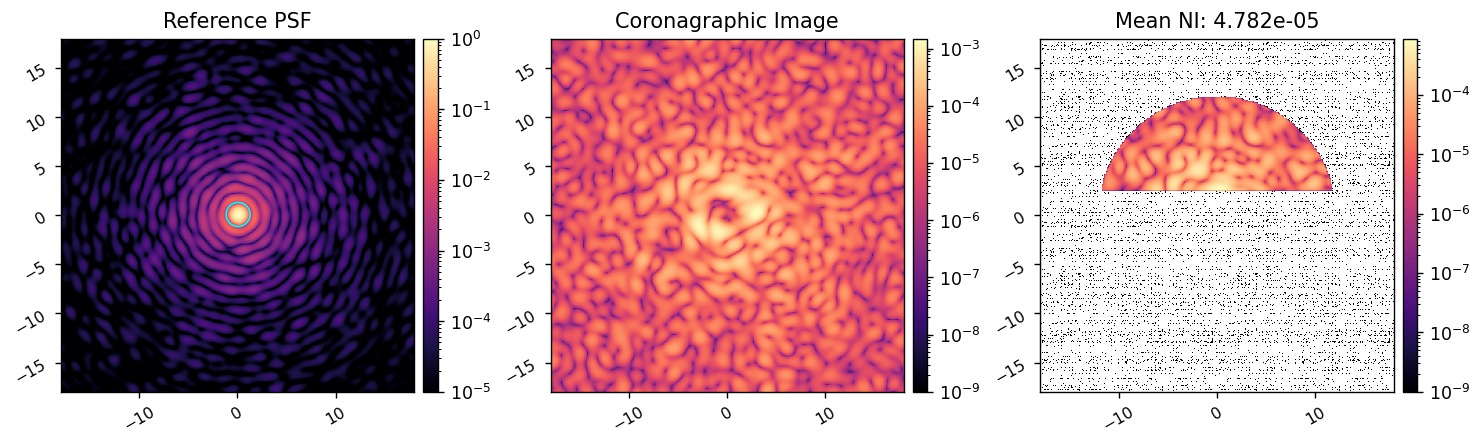

In [14]:
reload(esc)
reload(stppsf.dm)

M = esc.single()
M.wfes = wfes

ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
ref_coro_im = M.snap()

iwa = 2.5
owa = 12
rot = 270
control_mask = lina.utils.create_annular_focal_plane_mask(M.npsf, M.psf_pixelscale_lamD, iwa, owa, edge=iwa, rotation=rot)
mean_ni = xp.mean(ref_coro_im[control_mask])

psf_center = (M.psf_pixelscale_lamD/2, M.psf_pixelscale_lamD/2)
imshow3(ref_psf/M.Imax_ref, ref_coro_im, control_mask*ref_coro_im, 
        'Reference PSF', 'Coronagraphic Image', f'Mean NI: {mean_ni:.3e}', 
        lognorm=True, vmin1=1e-5, vmin2=1e-9, vmin3=1e-9, 
        npix=M.npsf, pxscl=M.psf_pixelscale_lamD, 
        patches1=[Circle(psf_center, 1.22, fill=False, color='cyan')])

In [7]:
reload(lina)
poke_amp = 1e-9
poke_modes = lina.utils.create_all_poke_modes(M.dm_mask)



Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=789.049 sec.
Jacobian built in 789.049 sec


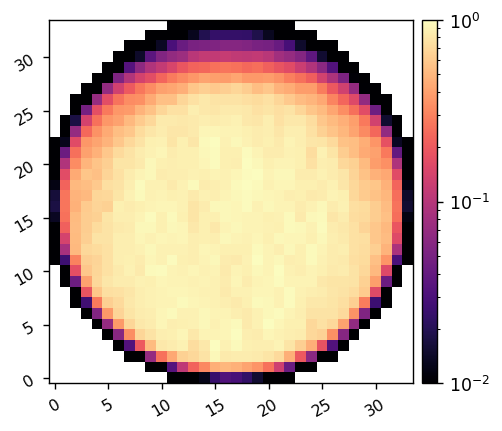

In [8]:
reload(lina.efc)
jac, response_cube = lina.efc.calibrate(M,
                                        poke_modes,
                                        #  poke_modes[800:951], 
                                        poke_amp,
                                        control_mask, 
                                        plot=True,
                                        return_all=True
                                        )

In [9]:
utils.save_fits(f'example-data/{today}_esc_fresnel_efc_response_cube.fits', response_cube)

Saved data to:  example-data/20240913_esc_fresnel_efc_response_cube.fits


In [145]:
reload(utils)
response_cube = utils.load_fits(f'example-data/{today}_esc_fresnel_efc_response_cube.fits')

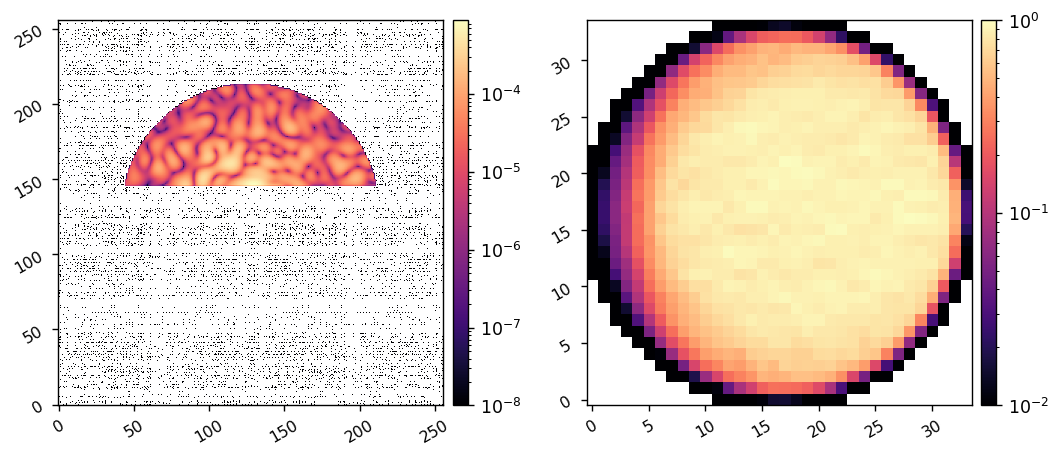

In [10]:
iwa = 2.5
owa = 12
rot = 270
control_mask = lina.utils.create_annular_focal_plane_mask(M.npsf, M.psf_pixelscale_lamD, iwa, owa, edge=iwa, rotation=rot)
Nmask = int(control_mask.sum())
mean_ni = xp.mean(ref_coro_im[control_mask])

jac = xp.zeros((2*Nmask, M.Nacts))
jac[::2] = response_cube[control_mask.ravel(), 0, :]
jac[1::2] = response_cube[control_mask.ravel(), 1, :]

dm_responses = jac[::2] + 1j*jac[1::2]
dm_responses = dm_responses.dot(xp.array(poke_modes))
dm_response_map = xp.sqrt(xp.mean(xp.abs(dm_responses)**2, axis=0)).reshape(M.Nact, M.Nact)
dm_response_map /= xp.max(dm_response_map)
imshow2(ref_coro_im*control_mask, dm_response_map, lognorm=True, vmin1=1e-8, vmin2=1e-2)

In [7]:
M.zero_dm()
all_ims = []
all_efs = []
all_commands = []


Beginning closed-loop EFC.
	Closed-loop iteration 16 / 18
Using model to compute electric field


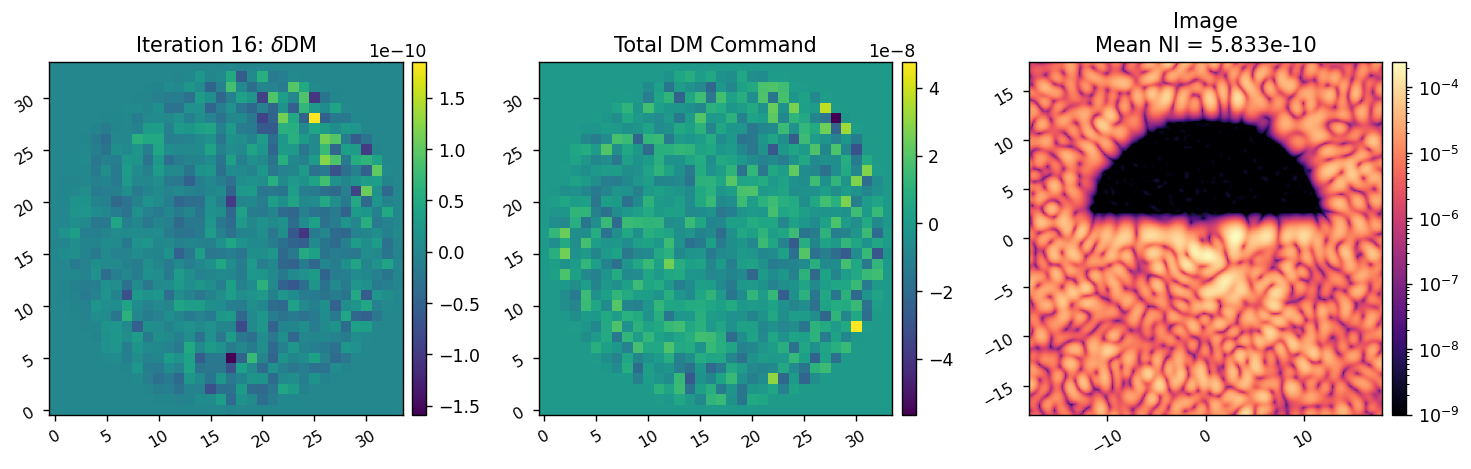

	Closed-loop iteration 17 / 18
Using model to compute electric field


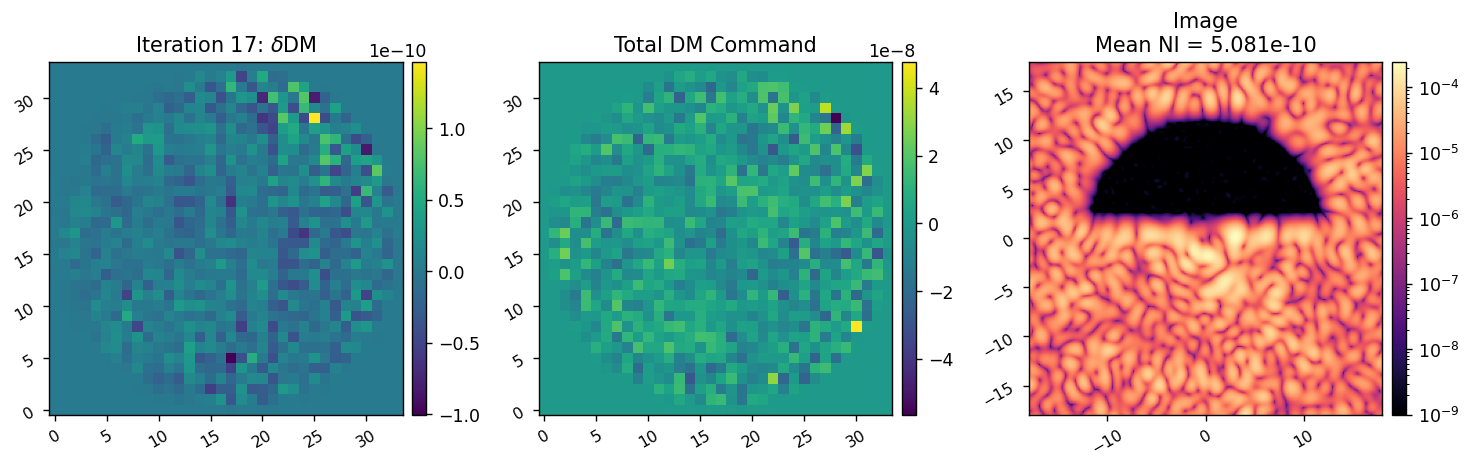

	Closed-loop iteration 18 / 18
Using model to compute electric field


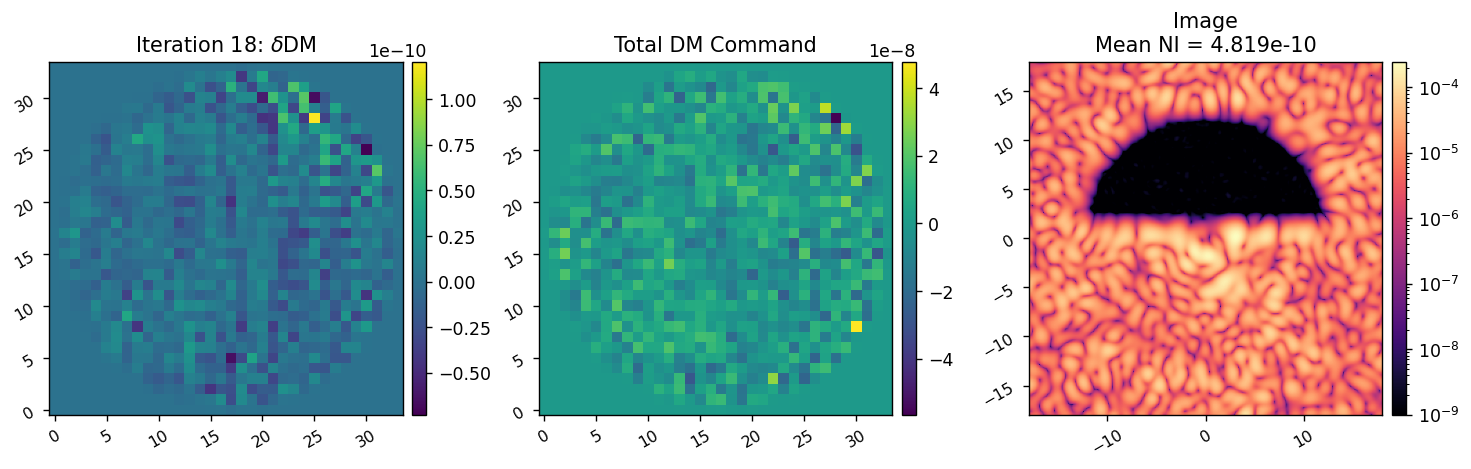

EFC completed in 4.430 sec.


In [17]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac, -2.5)
# control_matrix = lina.utils.beta_reg(jac, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

In [23]:
len(all_commands)

18

In [18]:
utils.save_fits(f'example-data/{today}_esc_fresnel_efc_dhc_270.fits', all_commands[-1])

Saved data to:  example-data/20240913_esc_fresnel_efc_dhc_270.fits


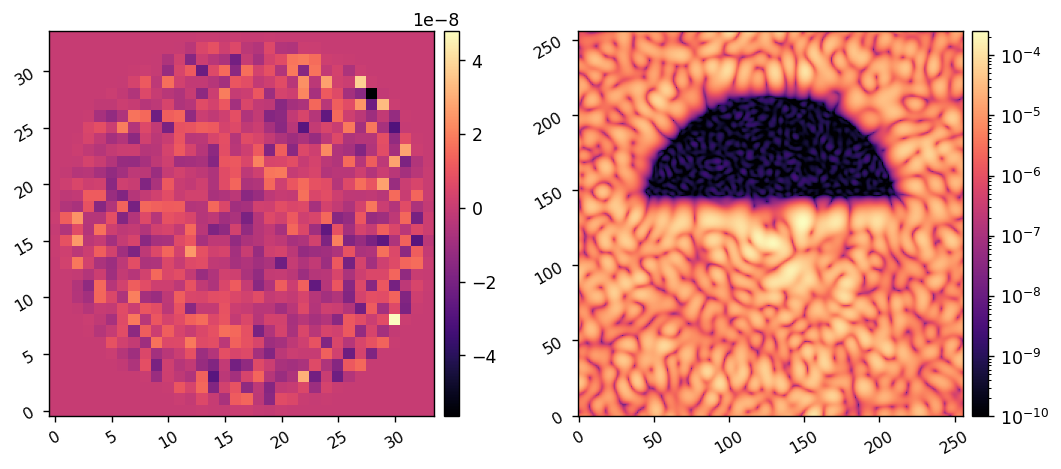

In [4]:
dhc = utils.load_fits(f'example-data/20240913_esc_fresnel_efc_dhc_270.fits')
M.set_dm(dhc)
dh_im = M.snap()

imshow2(dhc, dh_im, lognorm2=True, vmin2=1e-10)

# Expected jitter/pointing error is 40mas before M4, 10mas bewteen M4 and FSM, and then 5mas for the rest.

# Perform an initial propagation to compute a reference PSF that is used to normalize the coronagraphic images. 

In [7]:
1.100000000000000E-001 + (50*u.mas).to(u.degree).value

0.11001388888888888

In [8]:
(50*u.mas).to(u.degree).value

1.3888888888888891e-05

In [5]:
start_row = 22
end_row = 128 - 22

surf_nums = np.loadtxt('../stppsf/esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=0, encoding="utf-16", dtype=int)

xc_on_axis = np.loadtxt('../stppsf/esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_on_axis = np.loadtxt('../stppsf/esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_50mas_x = np.loadtxt('../stppsf/esc_ray_50mas_x.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_50mas_x = np.loadtxt('../stppsf/esc_ray_50mas_x.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_50mas_y = np.loadtxt('../stppsf/esc_ray_50mas_y.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_50mas_y = np.loadtxt('../stppsf/esc_ray_50mas_y.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)



In [6]:
reload(esc_optics)

seed = 1234
optic_keys = list(esc_optics.zemax_inds.keys())
beamwalk_mats = {}
for i in range(len(optic_keys)):
    surf_num = esc_optics.zemax_inds[optic_keys[i]]
    surf_ind = np.where(surf_num==surf_nums)[0][0]
    print(optic_keys[i])
    print(surf_num, surf_ind)
    M_bw = np.array([
        [xc_on_axis[surf_ind] - xc_50mas_x[surf_ind], xc_on_axis[surf_ind] - xc_50mas_y[surf_ind]],
        [yc_on_axis[surf_ind] - yc_50mas_x[surf_ind], yc_on_axis[surf_ind] - yc_50mas_y[surf_ind]]
    ]) * u.mm/ (50*u.mas)
    print(M_bw)
    beamwalk_mats.update({optic_keys[i]: M_bw})


m1
4 3
[[5.79800001e-07 2.00000159e-10]
 [0.00000000e+00 5.80000001e-07]] mm / mas
m2
5 4
[[-3.63238000e-05  1.04000000e-07]
 [-2.20000004e-09 -3.65406000e-05]] mm / mas
m3
6 5
[[-3.919788e-04  1.548200e-06]
 [ 2.642000e-07 -3.928214e-04]] mm / mas
m4
9 8
[[ 2.4466e-07 -6.2476e-07]
 [-5.6646e-07 -3.4695e-06]] mm / mas
wcc_fp
12 11
[[4.80693020e-04 7.25300000e-06]
 [7.26830400e-06 4.87232774e-04]] mm / mas
oap1
21 20
[[ 6.6750016e-04 -1.6380400e-06]
 [-1.6088000e-06  6.6342340e-04]] mm / mas
fm1
23 22
[[ 4.89312e-04 -1.13638e-06]
 [-1.11340e-06  5.15166e-04]] mm / mas
pupil_mask
27 26
[[0. 0.]
 [0. 0.]] mm / mas
oap2
30 29
[[-2.03320000e-07  7.27453000e-05]
 [-7.33840682e-05  2.13684004e-07]] mm / mas
ifp1
32 31
[[-2.77506000e-07  9.88544336e-05]
 [-9.52932494e-05  2.78051388e-07]] mm / mas
oap3
35 34
[[-3.12920000e-07  1.10546600e-04]
 [-1.11392347e-04  3.25623850e-07]] mm / mas
fsm
38 37
[[0. 0.]
 [0. 0.]] mm / mas
fm2
41 40
[[ 0.00000000e+00  0.00000000e+00]
 [ 6.92671446e-05 -2.0538

In [11]:
pointing = np.array([-120, -120])*u.mas
beamwalk_mats['m3'].dot(pointing)

<Quantity [0.04685167, 0.04710686] mm>

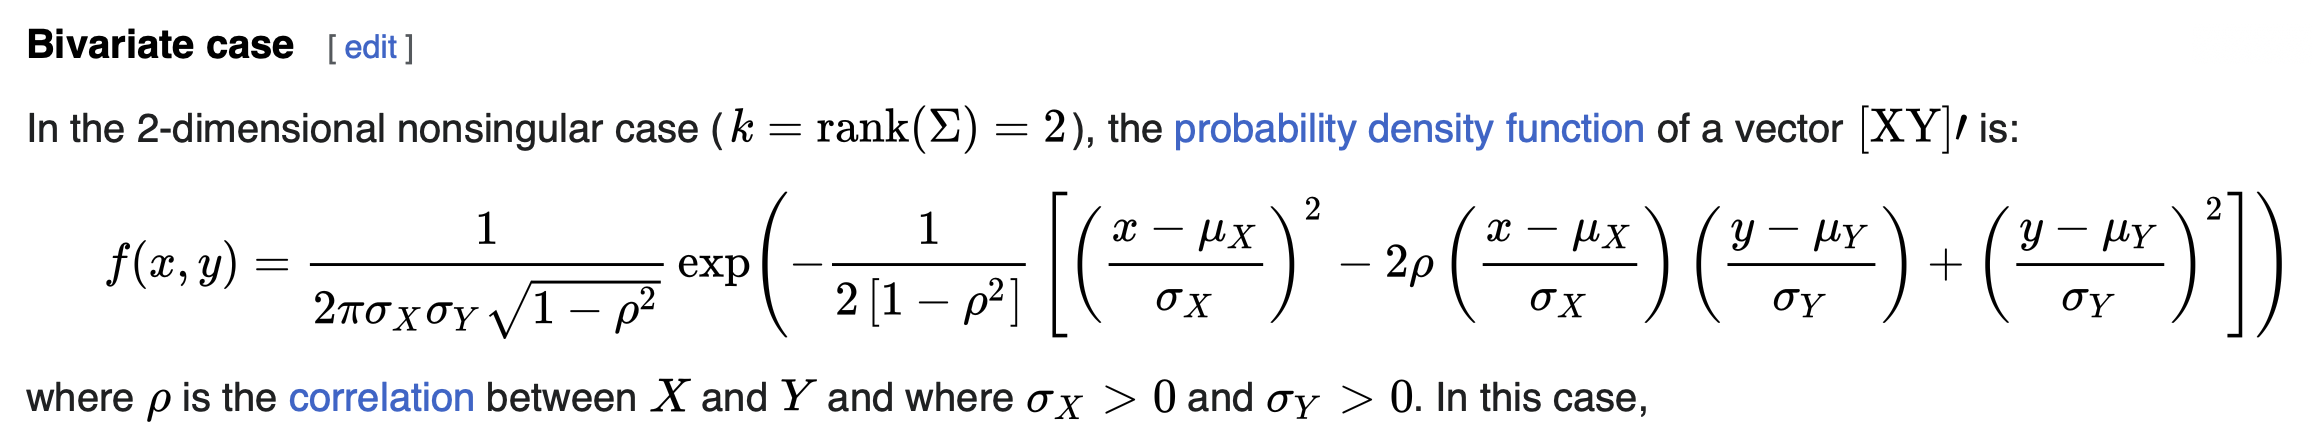


3600
(3600, 2)


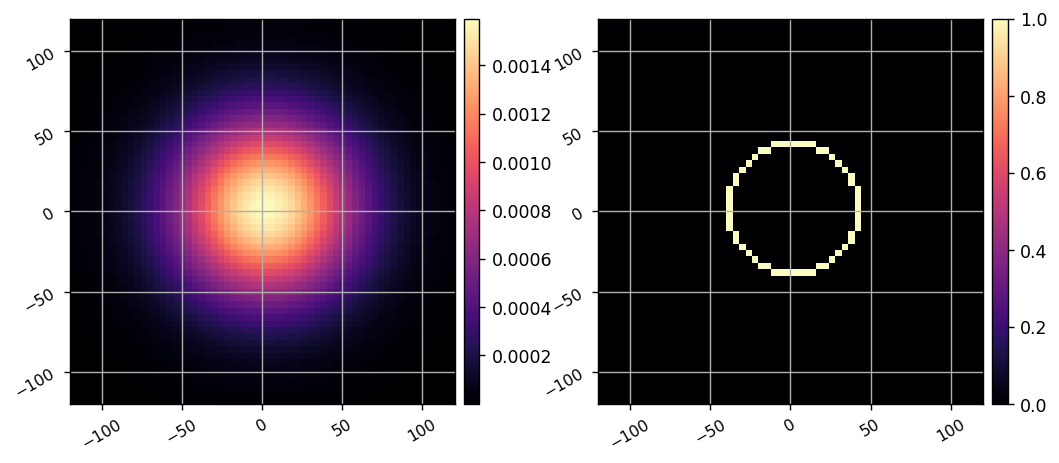

array(0.99456354)

In [7]:
jitter = 40*u.mas
pointing_sampling = 4*u.mas
Np = int(np.round( (6*jitter / pointing_sampling).decompose().value))
Nsamples = Np**2
print(Nsamples)

yc, xc = (xp.indices((Np, Np)) - Np//2)* pointing_sampling.to_value(u.mas)
rc = xp.sqrt(xc**2 + yc**2)
pdf_std = ( jitter.value-1.5 < rc ) * ( rc < jitter.value+2 )
pointing_samples = ensure_np_array ( xp.array([xc.flatten(), yc.flatten()]).T ) * u.mas
print(pointing_samples.shape)

amp = pointing_sampling.to_value(u.mas)**2 * 1/(2*xp.pi*jitter.to_value(u.mas)**2)
pointing_pdf = amp * xp.exp( -1/2 * ( (xc/jitter.to_value(u.mas))**2 + (yc/jitter.to_value(u.mas))**2 ) ) 
imshow2(pointing_pdf, pdf_std, 
        pxscl=pointing_sampling, grid=True)
xp.sum(pointing_pdf)

In [45]:
pointing_pdf.flatten()[1770]

array(0.00158361)

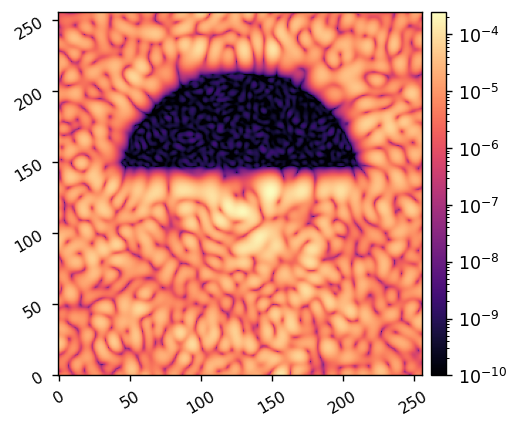

In [8]:
M.set_dm(dhc)
M.wfes = wfes
im = M.snap()
imshow1(im, lognorm=True, vmin=1e-10)

In [17]:
range(Nsamples)
np.arange(Nsamples)[::10]

array([   0,   10,   20,   30,   40,   50,   60,   70,   80,   90,  100,
        110,  120,  130,  140,  150,  160,  170,  180,  190,  200,  210,
        220,  230,  240,  250,  260,  270,  280,  290,  300,  310,  320,
        330,  340,  350,  360,  370,  380,  390,  400,  410,  420,  430,
        440,  450,  460,  470,  480,  490,  500,  510,  520,  530,  540,
        550,  560,  570,  580,  590,  600,  610,  620,  630,  640,  650,
        660,  670,  680,  690,  700,  710,  720,  730,  740,  750,  760,
        770,  780,  790,  800,  810,  820,  830,  840,  850,  860,  870,
        880,  890,  900,  910,  920,  930,  940,  950,  960,  970,  980,
        990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090,
       1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180, 1190, 1200,
       1210, 1220, 1230, 1240, 1250, 1260, 1270, 1280, 1290, 1300, 1310,
       1320, 1330, 1340, 1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420,
       1430, 1440, 1450, 1460, 1470, 1480, 1490, 15

In [10]:
import time

M.set_dm(dhc)

quiet = 1

shifts = []
N_wfe_optics = len(wfes)
wfe_keys = list(wfes.keys())
total_im = 0.0
start = time.time()
for i in np.arange(Nsamples):
    # if i>10: break
    pointing = pointing_samples[i]
    amp = pointing_pdf.flatten()[i]
    if not quiet: print(i, pointing, amp)
    wfes_with_bw = {}
    for j in range(N_wfe_optics): 
        # This for-loop shifts the WFE of each optics by the amount computed from the given pointing error 
        optic = wfe_keys[j]
        pxscl = wfes[optic].pixelscale
        Mbw = beamwalk_mats[optic]
        if j<=3:
            eff_pointing = pointing
        elif 3 < j & j <= 8:
            eff_pointing = pointing/4 # reduce pointing error by 4 between M4 and FSM to get the effective pointing
        elif 8 < j :
            eff_pointing = pointing/8 # reduce pointing error by 8 after FSM to get the effective pointing
        shift = Mbw.dot(eff_pointing)
        shift_pix = shift.to_value(u.mm) / pxscl.to_value(u.mm/u.pix)
        if not quiet:
            print('\t', optic)
            print('\t', pxscl)
            print('\t', shift)
            print('\t', shift_pix)

        shifted_opd = copy.copy(_scipy.ndimage.shift(wfes[optic].opd, (shift_pix[0], shift_pix[1])))
        shifted_wfe = poppy.ArrayOpticalElement(opd=shifted_opd, pixelscale=pxscl )
        wfes_with_bw.update({ optic : shifted_wfe })
        diff = wfes[optic].opd - shifted_wfe.opd
        if not quiet: imshow3(wfes[optic].opd, shifted_wfe.opd, diff, npix=128)
    M.wfes = wfes_with_bw
    im = M.snap()
    total_im += amp * im
    # imshow1(im, f'({pointing[0].value:.2f}, {pointing[1].value:.2f})', lognorm=True, vmin=1e-10)
    print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s", end='')
    print("\r", end="")


        
        

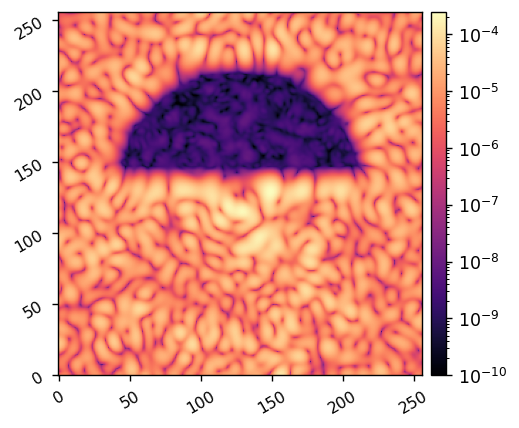

In [11]:
imshow1(total_im, lognorm=True, vmin=1e-10)

In [15]:
xp.mean(total_im[control_mask.astype(bool)])

array(1.93894483e-09)